In [1]:

"""
Conformer_rl Analysis Example
=============================
View the notebook in Google Colab: https://drive.google.com/drive/folders/1WAnTv4SGwEQHHqyMcbrExzUob_mOfTcM?usp=sharing
≠
This notebook gives examples of how the analysis functions in conformer_rl can be used.
The example data (example_data1.pickle, example_data2.pickle and example_data3.pickle) were all
data taken from different evaluation episodes of an actual run.

The full API reference for the analysis module can be found at: 
"""
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")
from conformer_rl import analysis

/mnt/nfs/work/yoyo-0916/miniconda3/envs/cfm0201a/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# import conformer_rl.analysis
# print(conformer_rl.analysis.__file__)

In [3]:
# analysis
# import inspect
# print(inspect.getsource(analysis))
# from conformer_rl.analysis import analysis as analysis_impl
# import inspect
# print(inspect.getsource(analysis_impl))
# wtf()  # Test call to new function

In [4]:
"""
Loading the data
----------------

We load the data by specifying the filenames of the .pickle files to load. Note that we can
load multiple sets of data. In this example, each data corresponds to a different evaluation episode
taken at different points in the training of an agent. By loading all three datasets we can compare the
performance of the agent across all three episodes.

We can also specify labels for the data (which will appear in the Seaborn plots).
"""
# Specify data files to load
files = [
    'example_data1.pickle',
    'example_data2.pickle',
    'example_data3.pickle'
]

# Specify labels for each data set
labels = [
    'example1',
    'example2',
    'example3'
]

data = analysis.load_data_from_pickle(files, labels)

{'mol': <rdkit.Chem.rdchem.Mol object at 0x7fabc5d4c630>,
 'step_data': {'energy': [28.095250611007504,
                          36.24667554925042,
                          28.766640299729403,
                          33.1268998375142,
                          30.027626356582605,
                          23.923685593038336,
                          28.507984091090872,
                          27.10398759902497,
                          24.29903794328062,
                          29.0935658833843,
                          27.623719590237886,
                          27.525788710311325,
                          29.167864873072144,
                          29.051402140030213,
                          34.33972588386167,
                          23.091667241025952,
                          29.536341505159896,
                          26.92892816307908,
                          29.20336533376687,
                          26.731605135268286,
                          28.902

/mnt/nfs/work/yoyo-0916/miniconda3/envs/cfm0201a/lib/python3.9/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


<Axes: xlabel='run', ylabel='total_rewards'>

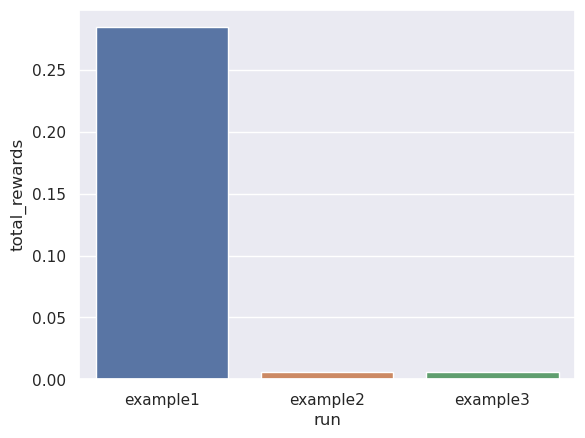

In [5]:
"""
bar_plot_episodic is used to compare any single scaler value across all sets of data.
In this example we visualize the total reward (sum of all rewards in the episode) across all three episodes.
"""
analysis.bar_plot_episodic("total_rewards", data)

/mnt/nfs/work/yoyo-0916/miniconda3/envs/cfm0201a/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/mnt/nfs/work/yoyo-0916/miniconda3/envs/cfm0201a/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/mnt/nfs/work/yoyo-0916/miniconda3/envs/cfm0201a/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/mnt/n

(<Figure size 2000x800 with 3 Axes>,
 array([<Axes: xlabel='energy', ylabel='Count'>,
        <Axes: xlabel='energy', ylabel='Count'>,
        <Axes: xlabel='energy', ylabel='Count'>], dtype=object))

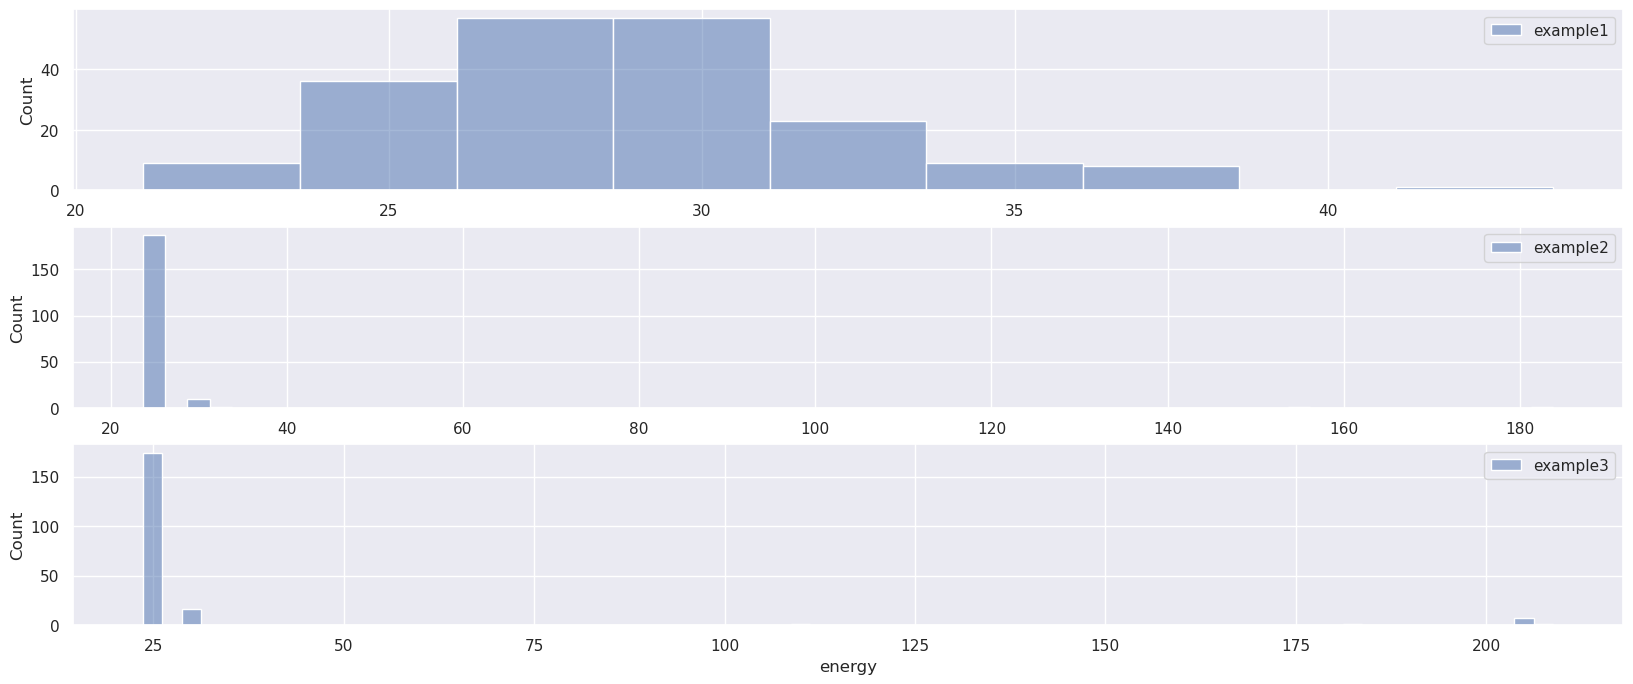

In [6]:
"""
histogram_episodic creates a histogram for each data set for the given key. In this case we will be creating
histogram of the energies of the conformers gneerated in each episode.
"""
analysis.histogram_episodic('energy', data, binwidth=2.5, figsize=(20, 8))

/mnt/nfs/work/yoyo-0916/miniconda3/envs/cfm0201a/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/mnt/nfs/work/yoyo-0916/miniconda3/envs/cfm0201a/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/mnt/nfs/work/yoyo-0916/miniconda3/envs/cfm0201a/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='energy', ylabel='Count'>)

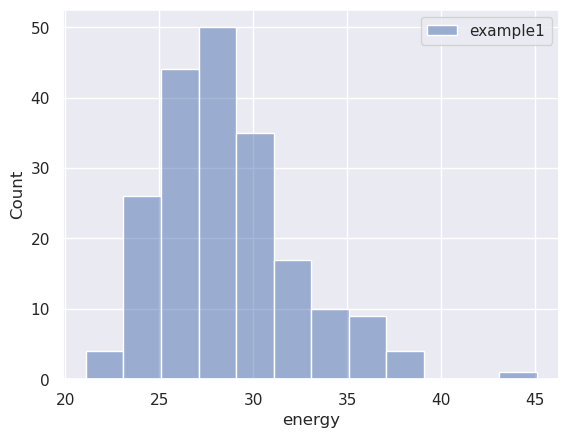

In [7]:
"""
We can also view individual histograms or compare a subset of the episodes in an overlayed histogram using histogram_select_episodes().
"""
analysis.histogram_select_episodes(key='energy', data=data, episodes=[0], binwidth=2)

(<Figure size 800x2000 with 6 Axes>,
 array([<Axes: xlabel='example1'>, <Axes: xlabel='example2'>,
        <Axes: xlabel='example3'>], dtype=object))

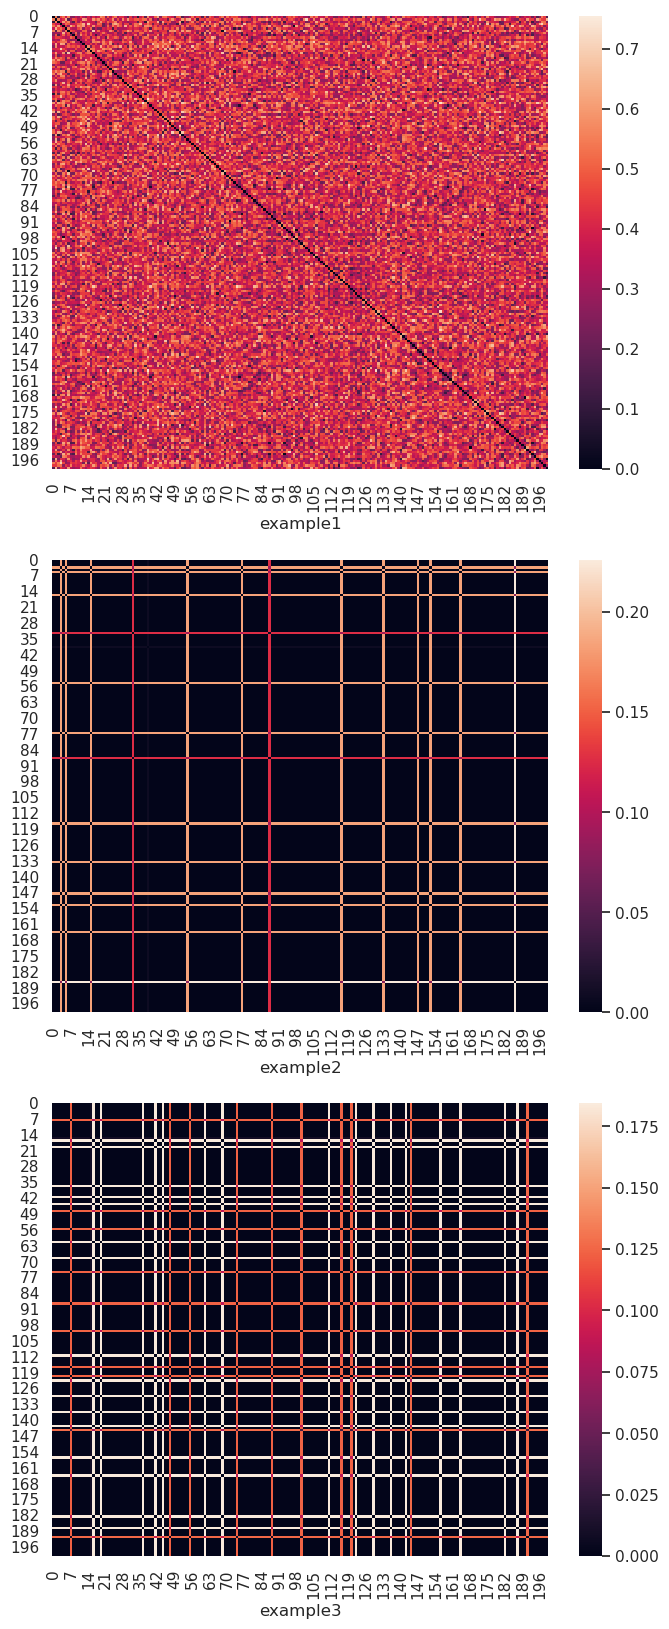

In [8]:
"""
calculate_tfd() calculates the TFD (Torsional Fingerprint Deviation) matrix between all conformers for each dataset.
The TFD measures how similar the conformers are to each other and is helpful for determining the diversity of the conformers generated.
"""
analysis.calculate_tfd(data)

"""
We can then visualize the TFD matrices generated for each dataset.

Notice that second and third datasets have a lot of conformer pairs with low TFD. This means
that the agent generated many duplicate conformers.
"""
analysis.heatmap_episodic('tfd_matrix', data, figsize=(8, 20))

/mnt/nfs/work/yoyo-0916/miniconda3/envs/cfm0201a/lib/python3.9/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


<Axes: xlabel='run', ylabel='tfd_total'>

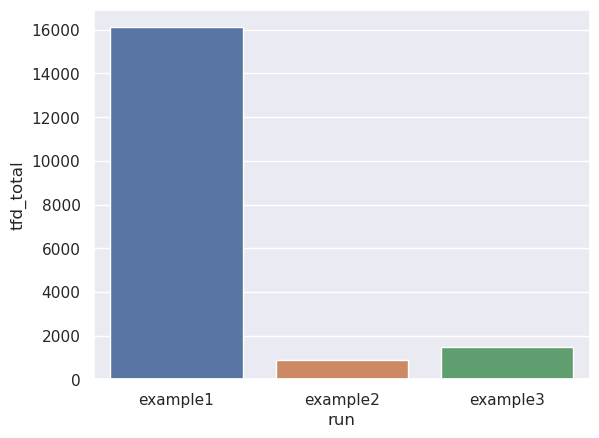

In [9]:
"""
We can also visualize the sum of the TFD matrices as a measure of the
diversity of the generated conformers for each dataset.
"""
analysis.bar_plot_episodic('tfd_total', data)

In [10]:
"""
We can visualize a single molecule from one of the datasets.
"""
analysis.drawConformer(data['mol'][0], confId=5, size=(500,300))

Generating 3D view for conformer ID: 5
Displaying conformer ID: 5


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [11]:
"""
We can also choose a conformer from each dataset and compare them.
"""
view = analysis.drawConformer_episodic(data, confIds=[1, 10, 15], style='stick')
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [12]:
"""
We can also visualize multiple generated conformers within a dataset.
"""
runIds = [0, 5, 10]
for id in runIds:
    view = analysis.drawConformer(data['mol'][0], confId=id, style='stick')
    view.show()

Generating 3D view for conformer ID: 0
Displaying conformer ID: 0


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Generating 3D view for conformer ID: 5
Displaying conformer ID: 5


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Generating 3D view for conformer ID: 10
Displaying conformer ID: 10


3Dmol.js failed to load for some reason. Please check your browser console for error messages.